# Loan Prediction Competition

#Huggin face user: Weegeex

---



In this workshop, we will apply ensemble methods such as Random Forest and Gradient Boosting to a loan prediction dataset. The dataset used is a modified subset of the **Loan Prediction Problem Dataset** from Kaggle ([link](https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset)).

## Objective
The task is to predict whether a loan application will be approved based on applicant information.

![Loan Prediction Competition](https://drive.google.com/uc?id=1eipuAdG46mfAgm-KSFth_YEazhJAZHVx)



## Loading the Data

The training dataset is loaded from the **[train.csv](https://drive.google.com/file/d/1Ejs0yaRm3NxFOVIhwQphoDz8voJl6NQx/view?usp=sharing)** file using Pandas. After loading, we inspect the first few rows to understand its structure and check for missing values. Basic preprocessing steps, such as handling null values and encoding categorical variables, will be performed before modeling.


In [ ]:
!pip install shap
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
import warnings
import lightgbm as lgb
from sklearn.model_selection import cross_val_predict

warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Random seed para reproducibilidad
RANDOM_STATE = 42

# Rutas de archivos
DATA_PATH = '/content/drive/MyDrive/Eafit/'
TRAIN_FILE = DATA_PATH + 'train.csv'
TEST_FILE = DATA_PATH + 'test_no_label.csv'

In [ ]:
#Let's load the data
# Carguemos los datos:
data = pd.read_csv('/content/drive/MyDrive/Eafit/train.csv')
data

,id,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001535,Male,No,0,Graduate,No,3254,0.0,50.0,360.0,1.0,Urban,Y
1,LP001792,Male,Yes,1,Graduate,No,3315,0.0,96.0,360.0,1.0,Semiurban,Y
2,LP002443,Male,Yes,2,Graduate,No,3340,1710.0,150.0,360.0,0.0,Rural,N
3,LP002517,Male,Yes,1,Not Graduate,No,2653,1500.0,113.0,180.0,0.0,Rural,N
4,LP001894,Male,Yes,0,Graduate,No,2620,2223.0,150.0,360.0,1.0,Semiurban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
486,LP001744,Male,No,0,Graduate,No,2971,2791.0,144.0,360.0,1.0,Semiurban,Y
487,LP002138,Male,Yes,0,Graduate,No,2625,6250.0,187.0,360.0,1.0,Rural,Y
488,LP001068,Male,Yes,0,Graduate,No,2799,2253.0,122.0,360.0,1.0,Semiurban,Y
489,LP001327,Female,Yes,0,Graduate,No,2484,2302.0,137.0,360.0,1.0,Semiurban,Y


In [ ]:
# Let's check the dataset description:
data.describe()


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,491.000000,491.000000,471.000000,479.000000,448.000000
mean,5529.997963,1569.537271,147.309979,341.286013,0.850446
std,6457.784318,2789.523475,87.096507,65.855043,0.357032
min,210.000000,0.000000,9.000000,12.000000,0.000000
25%,2906.000000,0.000000,100.000000,360.000000,1.000000
50%,3859.000000,1032.000000,128.000000,360.000000,1.000000
75%,5825.000000,2241.000000,168.000000,360.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000


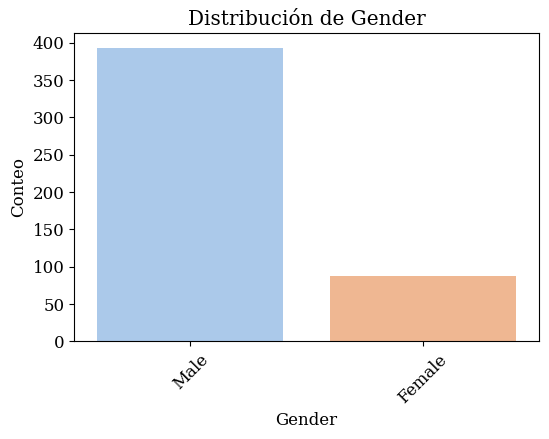

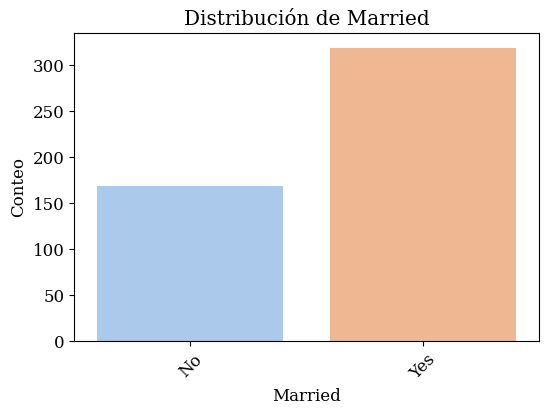

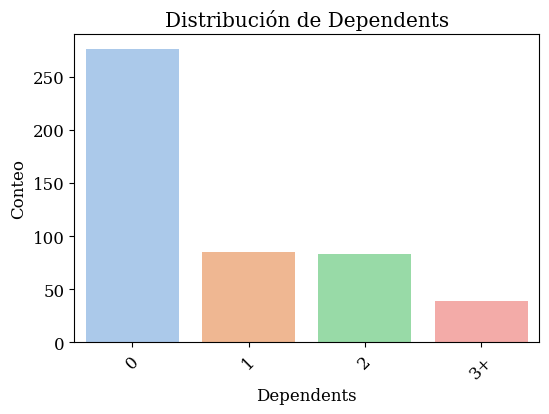

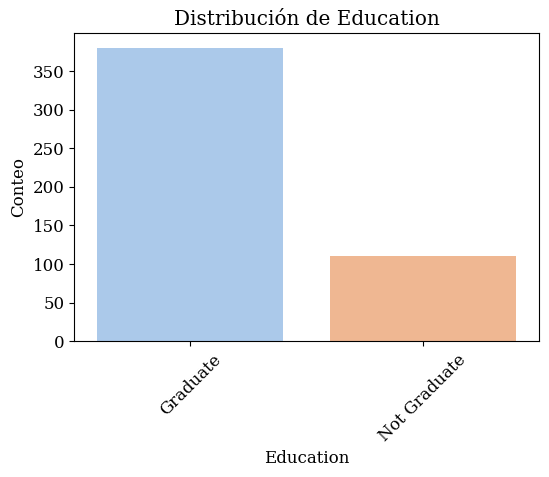

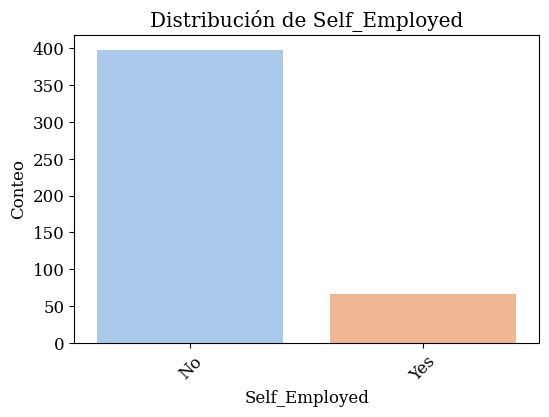

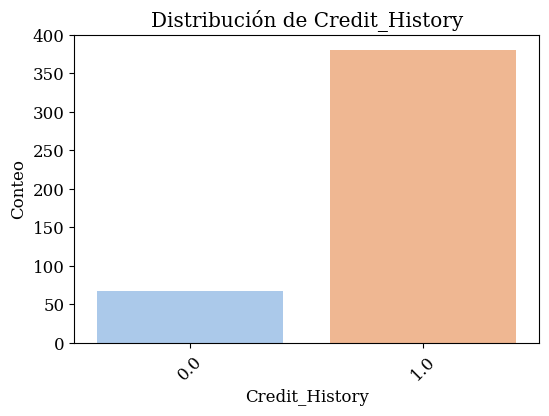

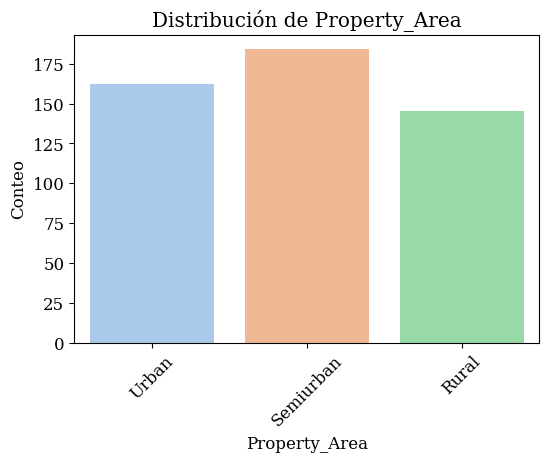

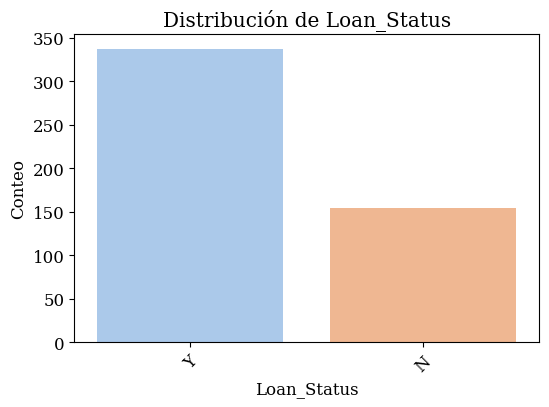

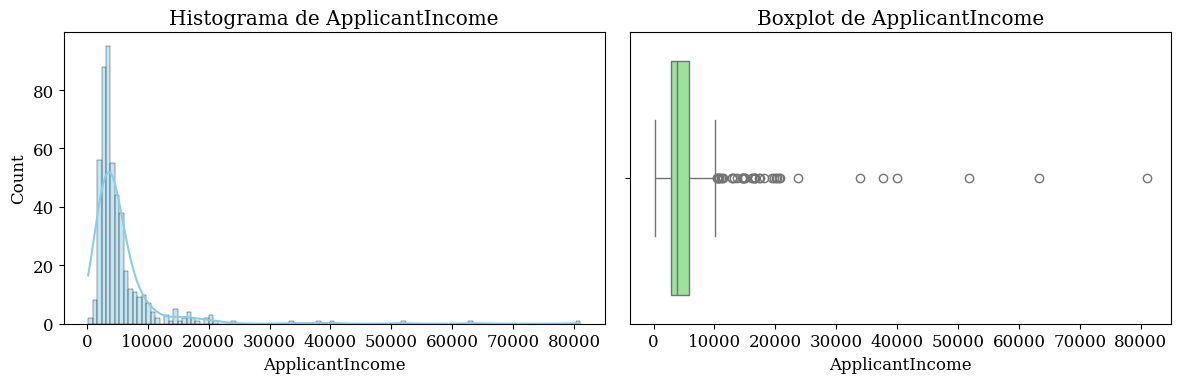

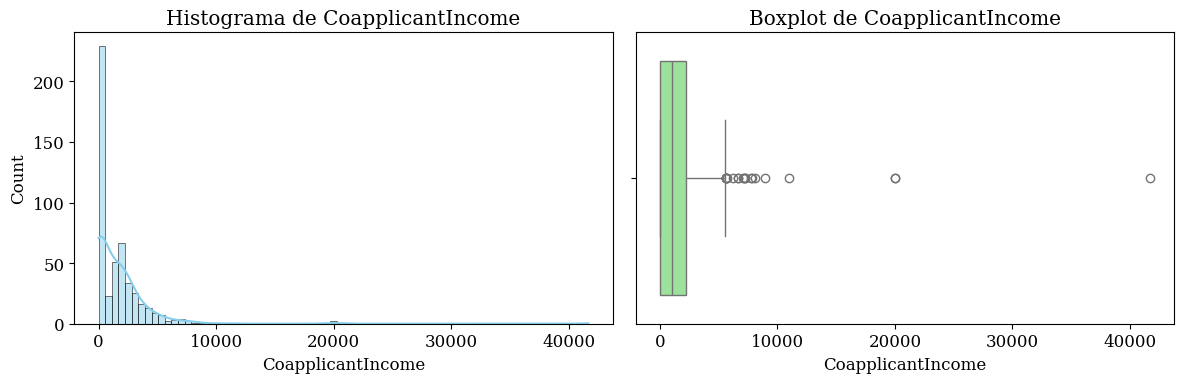

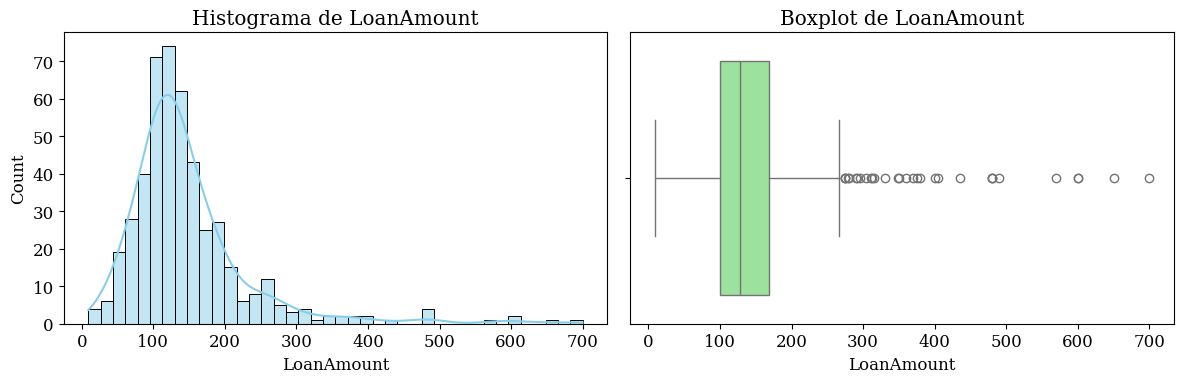

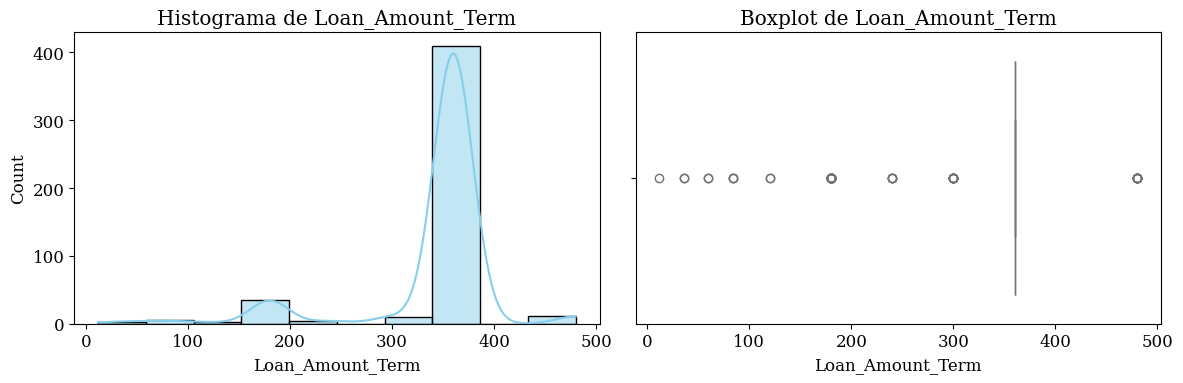

In [ ]:
# =====================================
# Exploración de distribuciones
# =====================================
import matplotlib.pyplot as plt
import seaborn as sns

# Definimos listas de variables
categoricas = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
               'Credit_History', 'Property_Area', 'Loan_Status']  # target incluida para ver balance
numericas = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

# -------------------------
# Categóricas: conteo
# -------------------------
for col in categoricas:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=data, palette="pastel")
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Conteo")
    plt.xticks(rotation=45)
    plt.show()

# -------------------------
# Numéricas: histograma + boxplot
# -------------------------
for col in numericas:
    fig, axes = plt.subplots(1,2, figsize=(12,4))

    # Histograma
    sns.histplot(data[col].dropna(), kde=True, ax=axes[0], color="skyblue")
    axes[0].set_title(f"Histograma de {col}")

    # Boxplot para ver outliers
    sns.boxplot(x=data[col], ax=axes[1], color="lightgreen")
    axes[1].set_title(f"Boxplot de {col}")

    plt.tight_layout()
    plt.show()

In [ ]:
# Revisión de valores nulos
missing_values = data.isnull().sum()
missing_percent = (missing_values / len(data)) * 100

missing_summary = pd.DataFrame({
    'Valores Nulos': missing_values,
    'Porcentaje (%)': missing_percent
}).sort_values(by='Porcentaje (%)', ascending=False)

print("Resumen de valores nulos:")
display(missing_summary)

Resumen de valores nulos:


,Valores Nulos,Porcentaje (%)
Credit_History,43,8.757637
Self_Employed,27,5.498982
LoanAmount,20,4.073320
Loan_Amount_Term,12,2.443992
Gender,11,2.240326
Dependents,8,1.629328
Married,3,0.610998
Education,0,0.000000
id,0,0.000000
CoapplicantIncome,0,0.000000


## Data Preprocessing Pipeline

Before modeling, we preprocess the dataset by handling missing values, encoding categorical variables, and scaling numerical features if necessary. This ensures that the data is clean and properly formatted for training machine learning models.


In [ ]:
def preprocess_loan_data(df):
    """
    Pipeline de preprocesamiento optimizado para datos de préstamos
    Versión limpia que logró 80% de accuracy

    Input: DataFrame crudo
    Output: DataFrame procesado listo para XGBoost
    """

    # Crear copia para no modificar original
    data = df.copy()

    # ===================
    # 1. IMPUTACIÓN INTELIGENTE
    # ===================

    # ✅ CLAVE: Manejo inteligente de Credit_History (esto dio el salto en accuracy)
    data['Credit_History_Missing'] = data['Credit_History'].isna().astype(int)
    data['Credit_History'].fillna(1.0, inplace=True)

    # Imputaciones simples
    data['Self_Employed'].fillna('No', inplace=True)
    data['Loan_Amount_Term'].fillna(360.0, inplace=True)
    data['Gender'].fillna('Male', inplace=True)
    data['Dependents'].fillna('0', inplace=True)
    data['Married'].fillna('No', inplace=True)
    data['Education'].fillna('Graduate', inplace=True)
    data['CoapplicantIncome'].fillna(0.0, inplace=True)

    # Imputación por grupos para ApplicantIncome
    if data['ApplicantIncome'].isnull().sum() > 0:
        median_by_group = data.groupby(['Education', 'Self_Employed'])['ApplicantIncome'].median()
        for idx in data[data['ApplicantIncome'].isnull()].index:
            education = data.loc[idx, 'Education']
            self_employed = data.loc[idx, 'Self_Employed']
            if (education, self_employed) in median_by_group.index:
                data.loc[idx, 'ApplicantIncome'] = median_by_group[education, self_employed]
            else:
                data.loc[idx, 'ApplicantIncome'] = data['ApplicantIncome'].median()

    # Imputación por grupos para LoanAmount
    if data['LoanAmount'].isnull().sum() > 0:
        median_by_group = data.groupby(['Education', 'Property_Area'])['LoanAmount'].median()
        for idx in data[data['LoanAmount'].isnull()].index:
            education = data.loc[idx, 'Education']
            property_area = data.loc[idx, 'Property_Area']
            if (education, property_area) in median_by_group.index:
                data.loc[idx, 'LoanAmount'] = median_by_group[education, property_area]
            else:
                data.loc[idx, 'LoanAmount'] = data['LoanAmount'].median()

    # ===================
    # 2. TRANSFORMACIONES LOGARÍTMICAS
    # ===================

    data['log_ApplicantIncome'] = np.log(data['ApplicantIncome'])
    data['log_CoapplicantIncome'] = np.log1p(data['CoapplicantIncome'])
    data['log_LoanAmount'] = np.log(data['LoanAmount'])

    # ===================
    # 3. FEATURE ENGINEERING
    # ===================

    # Variables base
    total_income = data['ApplicantIncome'] + data['CoapplicantIncome']

    # Features principales
    data['total_income'] = total_income
    data['loan_to_income_ratio'] = data['LoanAmount'] / (total_income / 12)
    data['coapplicant_contribution'] = data['CoapplicantIncome'] / total_income

    # Income per person
    dependents_numeric = data['Dependents'].replace('3+', '3').astype(int) + 1
    data['income_per_person'] = total_income / dependents_numeric

    # Ratios logarítmicos
    log_monthly_payment = data['log_LoanAmount'] - np.log(data['Loan_Amount_Term'])
    log_monthly_income = np.log(total_income) - np.log(12)
    data['log_monthly_payment_to_income_ratio'] = log_monthly_payment - log_monthly_income

    # Categorización
    data['income_category'] = pd.cut(total_income,
                                   bins=[0, 3000, 6000, 10000, np.inf],
                                   labels=['Low', 'Medium', 'High', 'Very_High'])

    data['loan_size_category'] = pd.cut(data['LoanAmount'],
                                      bins=[0, 100, 150, 200, np.inf],
                                      labels=['Small', 'Medium', 'Large', 'Very_Large'])

    # Perfiles de riesgo y estabilidad
    data['high_risk_profile'] = ((data['Credit_History'] == 0) |
                                (data['Self_Employed'] == 'Yes') |
                                (data['loan_to_income_ratio'] > 0.4)).astype(int)

    married_flag = (data['Married'] == 'Yes').astype(int)
    education_flag = (data['Education'] == 'Graduate').astype(int)
    data['financial_stability'] = (married_flag &
                                  education_flag &
                                  (data['Credit_History'] == 1.0)).astype(int)

    # ✅ FEATURE INTERACTIONS (clave para el 80%)
    data['credit_missing_interaction'] = data['Credit_History'] * data['Credit_History_Missing']
    data['married_coapplicant_synergy'] = married_flag * (data['CoapplicantIncome'] > 0).astype(int)

    education_flag = (data['Education'] == 'Graduate').astype(int)
    self_employed_flag = (data['Self_Employed'] == 'Yes').astype(int)
    data['education_employment_interaction'] = education_flag * self_employed_flag

    # Wealthy conservative borrower
    income_q75 = total_income.quantile(0.75)
    loan_q25 = data['LoanAmount'].quantile(0.25)
    high_income_flag = (total_income > income_q75)
    small_loan_flag = (data['LoanAmount'] < loan_q25)
    data['wealthy_conservative_borrower'] = (high_income_flag & small_loan_flag).astype(int)

    # Term-amount mismatch
    long_term = (data['Loan_Amount_Term'] >= 360)
    short_term = (data['Loan_Amount_Term'] < 360)
    large_loan = (data['LoanAmount'] > data['LoanAmount'].quantile(0.75))
    small_loan = (data['LoanAmount'] <= data['LoanAmount'].quantile(0.25))
    data['term_amount_mismatch'] = ((long_term & small_loan) | (short_term & large_loan)).astype(int)

    # Property-income context
    urban_flag = (data['Property_Area'] == 'Urban')
    rural_flag = (data['Property_Area'] == 'Rural')
    high_income_percentile = (total_income > total_income.quantile(0.8))
    data['urban_high_income'] = (urban_flag & high_income_percentile).astype(int)
    data['rural_high_income'] = (rural_flag & high_income_percentile).astype(int)

    # ===================
    # 4. ENCODING
    # ===================

    # Variables binarias
    data['Gender_Male'] = (data['Gender'] == 'Male').astype(int)
    data['Married_Yes'] = (data['Married'] == 'Yes').astype(int)
    data['Self_Employed_Yes'] = (data['Self_Employed'] == 'Yes').astype(int)
    data['Education_Graduate'] = (data['Education'] == 'Graduate').astype(int)

    # One-Hot Encoding
    dependents_dummies = pd.get_dummies(data['Dependents'], prefix='Dependents', drop_first=True)
    property_dummies = pd.get_dummies(data['Property_Area'], prefix='Property_Area', drop_first=True)
    income_dummies = pd.get_dummies(data['income_category'], prefix='Income', drop_first=True)
    loan_size_dummies = pd.get_dummies(data['loan_size_category'], prefix='LoanSize', drop_first=True)

    # Concatenar dummies
    data = pd.concat([data, dependents_dummies, property_dummies,
                     income_dummies, loan_size_dummies], axis=1)

    # Target encoding
    if 'Loan_Status' in data.columns:
        data['Loan_Status'] = (data['Loan_Status'] == 'Y').astype(int)

    # ===================
    # 5. LIMPIEZA FINAL
    # ===================

    # Eliminar variables categóricas originales
    categorical_to_drop = ['Gender', 'Married', 'Self_Employed', 'Education',
                          'Dependents', 'Property_Area', 'income_category', 'loan_size_category']

    # Eliminar transformaciones menos útiles
    numerical_to_drop = ['log_CoapplicantIncome']

    # Eliminar solo las que existen
    all_to_drop = [col for col in categorical_to_drop + numerical_to_drop if col in data.columns]
    data.drop(all_to_drop, axis=1, inplace=True)

    return data

# Model Training and Evaluation  

We train machine learning models, such as Random Forest, Gradient Boosting or XGBoost, to predict loan approval. The models are evaluated using appropriate metrics, and hyperparameter tuning is performed to optimize their performance.

In this section, we define the steps for training and evaluating the models.  

## Steps:  
1. **Define the hyperparameters**: Set initial values for model parameters.  
2. **Choose the cross-validation strategy**: Split the dataset into training and validation sets using an appropriate method.  
3. **Train the model**: Fit the model on training data using the defined hyperparameters.  
4. **Evaluate performance**: Use cross-validation to assess the model’s predictive ability.  
5. **Tune hyperparameters (if necessary)**: Optimize parameters for better performance.  

## Hyperparameters  
We define key hyperparameters for Random Forest and Gradient Boosting models, such as:  
- **n_estimators**: Number of trees in the ensemble.  
- **max_depth**: Maximum depth of each tree.  
- **learning_rate** (for boosting models): Controls step size for weight updates.  
- **min_samples_split**: Minimum samples required to split a node.  
- **min_samples_leaf**: Minimum samples required in a leaf node.  

## Cross-Validation Strategy  
To ensure reliable model evaluation, we use **K-Fold Cross-Validation**, which splits the dataset into **K** subsets (folds). The model is trained on **K-1** folds and tested on the remaining fold, repeating the process **K** times. This helps in reducing variance and providing a better generalization estimate.  




In [ ]:
def evaluate_with_cv(model, X, y, cv_splits):
    """
    Evalúa modelo con cross validation
    Retorna métricas promedio y por fold
    """

    metrics = {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'roc_auc': []}

    for fold, (train_idx, val_idx) in enumerate(cv_splits):
        # Split data
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # Fit and predict
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        y_pred_proba = model.predict_proba(X_val)[:, 1]

        # Calculate metrics
        metrics['accuracy'].append(accuracy_score(y_val, y_pred))
        metrics['precision'].append(precision_score(y_val, y_pred, pos_label=1))
        metrics['recall'].append(recall_score(y_val, y_pred, pos_label=1))
        metrics['f1'].append(f1_score(y_val, y_pred, pos_label=1))
        metrics['roc_auc'].append(roc_auc_score(y_val == 1, y_pred_proba))

    # Calculate means
    results = {metric: np.mean(values) for metric, values in metrics.items()}
    results['std'] = {metric: np.std(values) for metric, values in metrics.items()}

    return results


def print_cv_results(results, model_name="Model"):
    """
    Función helper para mostrar resultados de CV de forma clara
    """
    print(f"\n🏆 RESULTADOS {model_name}:")
    print(f"   📊 Accuracy: {results['accuracy']:.4f} (±{results['std']['accuracy']:.4f})")
    print(f"   📊 F1-Score: {results['f1']:.4f} (±{results['std']['f1']:.4f})")
    print(f"   📊 Precision: {results['precision']:.4f} (±{results['std']['precision']:.4f})")
    print(f"   📊 Recall: {results['recall']:.4f} (±{results['std']['recall']:.4f})")
    print(f"   📊 ROC-AUC: {results['roc_auc']:.4f} (±{results['std']['roc_auc']:.4f})")


def quick_evaluate(model, X, y, cv_folds=5, model_name="Model"):
    """
    Evaluación rápida con cross-validation
    Una sola función para todo el proceso
    """
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)
    cv_splits = list(cv.split(X, y))

    results = evaluate_with_cv(model, X, y, cv_splits)
    print_cv_results(results, model_name)

    return results

In [ ]:
def print_cv_results(results, model_name):
    """Imprime resultados de CV de forma limpia"""
    print(f"\n{model_name} - CV Results:")
    print(f"Accuracy:  {results['accuracy']:.4f} (±{results['std']['accuracy']:.4f})")
    print(f"F1-Score:  {results['f1']:.4f} (±{results['std']['f1']:.4f})")
    print(f"ROC-AUC:   {results['roc_auc']:.4f} (±{results['std']['roc_auc']:.4f})")


# Finalizing the Model: Training a Full Pipeline  

Once the best model parameters have been selected, it is essential to **train a complete pipeline** that explicitly separates **data preprocessing** and **model training**. This ensures that preprocessing steps are consistently applied to both training and unseen data.  

## Steps:  
1. **Train the data preprocessing pipeline**:  
   - Handle missing values.  
   - Encode categorical features.  
   - Scale numerical features (if necessary).  

2. **Train the classification pipeline**:  
   - Use the entire processed training dataset and the best model hyperparameters to fit the selected model to make final predictions.  

3. **Save the trained pipelines**:  
   - The preprocessing and classification models should be saved for deployment and inference.  

By structuring the pipeline this way, we maintain consistency between training and real-world predictions while ensuring that preprocessing does not introduce **data leakage**.  


In [ ]:
def optimize_random_forest(X, y, cv_folds=5):
    """
    Optimiza RandomForest con grid balanceado (ni muy rápido, ni muy lento)
    """

    # Grid balanceado - cubre rangos importantes sin ser excesivo
    param_grid = {
        'n_estimators': [100, 200, 300],        # 3 opciones suficientes
        'max_depth': [5, 10, None],             # Shallow, medium, sin límite
        'min_samples_split': [2, 5, 10],        # Control de overfitting
        'min_samples_leaf': [1, 2, 4],          # 3 opciones principales
        'max_features': ['sqrt'],               # 'sqrt' es generalmente el mejor
        'class_weight': ['balanced']            # Para datasets desbalanceados
    }
    # Total combinaciones: 3×3×3×3×1×1 = 81 (manejable)

    rf = RandomForestClassifier(random_state=RANDOM_STATE)
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)

    grid_search = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        cv=cv,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )

    print(f"🌲 Optimizando Random Forest...")
    print(f"   📊 Combinaciones a probar: {3*3*3*3*1*1}")

    grid_search.fit(X, y)

    print(f"✅ Mejor F1-Score: {grid_search.best_score_:.4f}")
    print(f"✅ Mejores parámetros: {grid_search.best_params_}")

    return {
        'model': grid_search.best_estimator_,
        'score': grid_search.best_score_,
        'params': grid_search.best_params_
    }


def optimize_gradient_boosting(X, y, cv_folds=5):
    """
    Optimiza GradientBoostingClassifier con grid balanceado
    """

    # Grid balanceado para Gradient Boosting
    param_grid = {
        'n_estimators': [100, 200, 300],        # 3 opciones
        'learning_rate': [0.05, 0.1, 0.15],     # Learning rates comunes
        'max_depth': [3, 4, 5],                 # Profundidades típicas
        'min_samples_split': [2, 5, 10],        # Control overfitting
        'subsample': [0.8, 0.9, 1.0]           # Sampling ratios
    }
    # Total: 3×3×3×3×3 = 243 combinaciones (un poco más que RF)

    gb = GradientBoostingClassifier(random_state=RANDOM_STATE)
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)

    grid_search = GridSearchCV(
        estimator=gb,
        param_grid=param_grid,
        cv=cv,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )

    print(f"🚀 Optimizando Gradient Boosting...")
    print(f"   📊 Combinaciones a probar: {3*3*3*3*3}")

    grid_search.fit(X, y)

    print(f"✅ Mejor F1-Score: {grid_search.best_score_:.4f}")
    print(f"✅ Mejores parámetros: {grid_search.best_params_}")

    return {
        'model': grid_search.best_estimator_,
        'score': grid_search.best_score_,
        'params': grid_search.best_params_
    }


def compare_multiple_models(X, y):
    """
    Compara múltiples modelos y retorna el mejor
    Útil para validar que XGBoost sigue siendo el mejor
    """

    print("🏁 COMPARANDO MÚLTIPLES MODELOS")
    print("=" * 50)

    results = {}

    # XGBoost (tu campeón actual)
    print("\n1️⃣  Evaluando XGBoost optimizado...")
    xgb_model = XGBClassifier(
        learning_rate=0.03,
        n_estimators=200,
        max_depth=3,
        min_child_weight=3,
        subsample=0.95,
        colsample_bytree=0.75,
        scale_pos_weight=2.5,
        random_state=RANDOM_STATE
    )
    results['XGBoost'] = quick_evaluate(xgb_model, X, y, model_name="XGBoost")

    # Random Forest
    print("\n2️⃣  Optimizando Random Forest...")
    rf_result = optimize_random_forest(X, y)
    results['RandomForest'] = {
        'accuracy': rf_result['score'],  # GridSearch usa F1, pero guardamos para comparar
        'f1': rf_result['score'],
        'model': rf_result['model']
    }

    # Gradient Boosting
    print("\n3️⃣  Optimizando Gradient Boosting...")
    gb_result = optimize_gradient_boosting(X, y)
    results['GradientBoosting'] = {
        'accuracy': gb_result['score'],
        'f1': gb_result['score'],
        'model': gb_result['model']
    }

    # Mostrar comparación final
    print(f"\n🏆 COMPARACIÓN FINAL:")
    print("=" * 50)
    for model_name, result in results.items():
        f1_score = result.get('f1', result.get('accuracy', 0))
        print(f"   {model_name:<20}: F1 = {f1_score:.4f}")

    # Encontrar el mejor
    best_model = max(results.keys(), key=lambda k: results[k].get('f1', results[k].get('accuracy', 0)))
    best_score = results[best_model].get('f1', results[best_model].get('accuracy', 0))

    print(f"\n🥇 GANADOR: {best_model} con F1 = {best_score:.4f}")

    return results

In [ ]:
def optimize_xgboost(X, y, cv_folds=5):
    """
    Optimiza XGBoost con grid balanceado centrado en parámetros que funcionan
    """

    # Grid centrado alrededor de tus parámetros exitosos del 80%
    param_grid = {
        'learning_rate': [0.02, 0.03, 0.04],           # Centrado en 0.03 ✅
        'n_estimators': [175, 200, 225],               # Centrado en 200 ✅ (ajustado más cerca)
        'max_depth': [3, 4, 5],                        # Centrado en 3 ✅
        'min_child_weight': [2, 3, 4],                 # Centrado en 3 ✅
        'subsample': [0.92, 0.95, 0.98],              # Centrado en 0.95 ✅ (ajustado más cerca)
        'colsample_bytree': [0.72, 0.75, 0.78],       # Centrado en 0.75 ✅ (ajustado más cerca)
        'scale_pos_weight': [2.25, 2.5, 2.75]         # Centrado en 2.5 ✅ (ajustado más cerca)
    }
    # Total: 3×3×3×3×3×3×3 = 2,187 combinaciones (manejable)

    xgb = XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        n_jobs=-1,
        verbosity=0
    )

    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)

    grid_search = GridSearchCV(
        estimator=xgb,
        param_grid=param_grid,
        cv=cv,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )

    print("Optimizando XGBoost...")
    print(f"   Combinaciones a probar: {3**7}")
    print(f"   Tiempo estimado: ~15-20 minutos")

    grid_search.fit(X, y)

    print(f"Mejor F1-Score: {grid_search.best_score_:.4f}")
    print(f"Mejores parámetros: {grid_search.best_params_}")

    # Comparar con tus parámetros actuales del 80%
    current_params = {
        'learning_rate': 0.03,
        'n_estimators': 200,
        'max_depth': 3,
        'min_child_weight': 3,
        'subsample': 0.95,
        'colsample_bytree': 0.75,
        'scale_pos_weight': 2.5
    }

    print(f"\nComparación con parámetros actuales (80%):")
    print(f"   Parámetros actuales: {current_params}")
    print(f"   ¿Mejora encontrada?: {'SÍ' if grid_search.best_score_ > 0.80 else 'Revisar'}")

    return {
        'model': grid_search.best_estimator_,
        'score': grid_search.best_score_,
        'params': grid_search.best_params_,
        'improvement': grid_search.best_score_ > 0.80
    }


def fine_tune_xgboost_around_best(X, y, base_params=None, cv_folds=5):
    """
    Fine-tuning muy específico alrededor de parámetros conocidos
    Útil cuando ya tienes buenos parámetros y quieres micro-optimizar
    """

    if base_params is None:
        # Usar tus parámetros del 80% como base
        base_params = {
            'learning_rate': 0.03,
            'n_estimators': 200,
            'max_depth': 3,
            'min_child_weight': 3,
            'subsample': 0.95,
            'colsample_bytree': 0.75,
            'scale_pos_weight': 2.5
        }

    # Grid muy fino alrededor de los valores base
    param_grid = {
        'learning_rate': [base_params['learning_rate'] - 0.005,
                         base_params['learning_rate'],
                         base_params['learning_rate'] + 0.005],
        'n_estimators': [base_params['n_estimators'] - 25,
                        base_params['n_estimators'],
                        base_params['n_estimators'] + 25],
        'colsample_bytree': [base_params['colsample_bytree'] - 0.05,
                            base_params['colsample_bytree'],
                            base_params['colsample_bytree'] + 0.05],
        'scale_pos_weight': [base_params['scale_pos_weight'] - 0.25,
                            base_params['scale_pos_weight'],
                            base_params['scale_pos_weight'] + 0.25],
        # Mantener fijos los que ya funcionan bien
        'max_depth': [base_params['max_depth']],
        'min_child_weight': [base_params['min_child_weight']],
        'subsample': [base_params['subsample']]
    }
    # Total: 3×3×3×3×1×1×1 = 81 combinaciones (muy rápido)

    xgb = XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        n_jobs=-1,
        verbosity=0
    )

    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)

    grid_search = GridSearchCV(
        estimator=xgb,
        param_grid=param_grid,
        cv=cv,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )

    print("Fine-tuning XGBoost alrededor de parámetros base...")
    print(f"   Parámetros base: {base_params}")
    print(f"   Combinaciones: 81 (búsqueda rápida)")

    grid_search.fit(X, y)

    print(f"Mejor F1-Score: {grid_search.best_score_:.4f}")
    print(f"Parámetros optimizados: {grid_search.best_params_}")

    return {
        'model': grid_search.best_estimator_,
        'score': grid_search.best_score_,
        'params': grid_search.best_params_,
        'base_params': base_params
    }

In [ ]:
# PIPELINE XGBOOST OPTIMIZADO - SIMPLE Y DIRECTO

# 1. Cargar datos
print("Cargando datos de entrenamiento...")
data = pd.read_csv(TRAIN_FILE)
print(f"Datos cargados: {data.shape}")

# 2. Conservar IDs
ids = data['id'].copy() if 'id' in data.columns else None

# 3. Preprocesar datos
print("\nAplicando preprocesamiento optimizado...")
data_processed = preprocess_loan_data(data)
print(f"Preprocesamiento completado: {data_processed.shape}")

# 4. Separar X e y
X = data_processed.drop(['Loan_Status', 'id'], axis=1) if 'id' in data_processed.columns else data_processed.drop('Loan_Status', axis=1)
y = data_processed['Loan_Status']
print(f"Features: {X.shape[1]}, Samples: {X.shape[0]}")

# 5. Optimizar XGBoost (incluye cross-validation interno)
print(f"\n{'='*50}")
print("OPTIMIZACIÓN XGBOOST - FASE 1")
print(f"{'='*50}")
xgb_results = optimize_xgboost(X, y)

# 6. Evaluación detallada del mejor modelo encontrado
print(f"\nEvaluación detallada del modelo optimizado:")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_splits = list(cv.split(X, y))
detailed_results = evaluate_with_cv(xgb_results['model'], X, y, cv_splits)
print_cv_results(detailed_results, "XGBoost Optimizado")

# 7. Feature Importance
if hasattr(xgb_results['model'], 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': xgb_results['model'].feature_importances_
    }).sort_values('importance', ascending=False)

    print(f"\nTOP 10 FEATURES:")
    print(feature_importance.head(10).to_string(index=False))

# 8. Comparación con modelo base (80%)
base_score = 0.80
improvement = detailed_results['f1'] - base_score
print(f"\nCOMPARACIÓN CON MODELO BASE:")
print(f"Score base (80%): {base_score:.4f}")
print(f"Score optimizado: {detailed_results['f1']:.4f}")
print(f"Mejora: {improvement:+.4f} ({(improvement/base_score)*100:+.2f}%)")

# 9. Resumen de la fase 1
print(f"\nRESUMEN FASE 1 - OPTIMIZACIÓN INICIAL:")
print(f"- Modelo: XGBoost Optimizado")
print(f"- F1-Score (CV): {detailed_results['f1']:.4f}")
print(f"- Accuracy (CV): {detailed_results['accuracy']:.4f}")
print(f"- ROC-AUC (CV): {detailed_results['roc_auc']:.4f}")
print(f"- Features: {X.shape[1]}")
print(f"- Parámetros óptimos encontrados: {xgb_results['params']}")

print(f"\n{'='*50}")
print("FASE 1 COMPLETADA - Listo para fine-tuning")
print(f"{'='*50}")



Optimizando XGBoost...
Optimizando XGBoost...
   Combinaciones a probar: 2187
   Tiempo estimado: ~15-20 minutos
Fitting 5 folds for each of 2187 candidates, totalling 10935 fits
Mejor F1-Score: 0.8691
Mejores parámetros: {'colsample_bytree': 0.72, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 200, 'scale_pos_weight': 2.5, 'subsample': 0.95}

Comparación con parámetros actuales (80%):
   Parámetros actuales: {'learning_rate': 0.03, 'n_estimators': 200, 'max_depth': 3, 'min_child_weight': 3, 'subsample': 0.95, 'colsample_bytree': 0.75, 'scale_pos_weight': 2.5}
   ¿Mejora encontrada?: SÍ

Evaluación detallada del modelo optimizado:

🏆 RESULTADOS XGBoost Optimizado:
   📊 Accuracy: 0.7962 (±0.0436)
   📊 F1-Score: 0.8691 (±0.0259)
   📊 Precision: 0.7797 (±0.0323)
   📊 Recall: 0.9822 (±0.0173)
   📊 ROC-AUC: 0.7654 (±0.0665)

TOP 10 FEATURES:
                            feature  importance
                     Credit_History    0.207016
                  high_r

In [ ]:
# ===========================================
# FINE-TUNING DINÁMICO
# Usa automáticamente los mejores parámetros encontrados en la optimización inicial
# ===========================================

print("\n" + "="*60)
print("FINE-TUNING DINÁMICO - MICRO-OPTIMIZACIÓN")
print("="*60)

# Verificar que existan los resultados de optimización inicial
if 'xgb_results' not in locals() or 'detailed_results' not in locals():
    print("ERROR: Ejecutar primero el pipeline de optimización inicial")
    print("Se requieren las variables 'xgb_results' y 'detailed_results'")
else:
    # Extraer parámetros base encontrados
    base_params = xgb_results['params']
    print(f"Parámetros base encontrados: {base_params}")

    # Construir grid dinámico alrededor de los parámetros encontrados
    param_grid = {}

    # Learning rate: ±0.005 del óptimo encontrado
    base_lr = base_params.get('learning_rate', 0.03)
    param_grid['learning_rate'] = [
        max(0.01, base_lr - 0.005),
        base_lr,
        min(0.1, base_lr + 0.005)
    ]

    # N estimators: ±25 del óptimo encontrado
    base_n_est = base_params.get('n_estimators', 200)
    param_grid['n_estimators'] = [
        max(50, base_n_est - 25),
        base_n_est,
        base_n_est + 25
    ]

    # Colsample bytree: ±0.05 del óptimo encontrado
    base_colsample = base_params.get('colsample_bytree', 0.75)
    param_grid['colsample_bytree'] = [
        max(0.5, base_colsample - 0.05),
        base_colsample,
        min(1.0, base_colsample + 0.05)
    ]

    # Scale pos weight: ±0.25 del óptimo encontrado
    base_scale = base_params.get('scale_pos_weight', 2.5)
    param_grid['scale_pos_weight'] = [
        max(1.0, base_scale - 0.25),
        base_scale,
        base_scale + 0.25
    ]

    # Mantener fijos los que ya funcionan bien
    param_grid['max_depth'] = [base_params.get('max_depth', 3)]
    param_grid['min_child_weight'] = [base_params.get('min_child_weight', 3)]
    param_grid['subsample'] = [base_params.get('subsample', 0.95)]

    print(f"\nGrid de fine-tuning generado:")
    for param, values in param_grid.items():
        if len(values) > 1:
            print(f"  {param}: {values}")
        else:
            print(f"  {param}: {values[0]} (fijo)")

    # Calcular combinaciones totales
    total_combinations = 1
    for values in param_grid.values():
        total_combinations *= len(values)
    print(f"\nCombinaciones a probar: {total_combinations}")

    # Ejecutar fine-tuning
    print("Ejecutando fine-tuning...")

    xgb_fine = XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        n_jobs=-1,
        verbosity=0
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    from sklearn.model_selection import GridSearchCV
    fine_grid_search = GridSearchCV(
        estimator=xgb_fine,
        param_grid=param_grid,
        cv=cv,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )

    fine_grid_search.fit(X, y)

    # Resultados del fine-tuning
    fine_tune_results = {
        'model': fine_grid_search.best_estimator_,
        'params': fine_grid_search.best_params_,
        'score': fine_grid_search.best_score_
    }

    print(f"Mejor F1-Score fine-tuning: {fine_tune_results['score']:.4f}")
    print(f"Mejores parámetros fine-tuning: {fine_tune_results['params']}")

    # Evaluación detallada del modelo fine-tuned
    print(f"\nEvaluación detallada del modelo fine-tuned:")
    cv_splits = list(cv.split(X, y))
    fine_detailed = evaluate_with_cv(fine_tune_results['model'], X, y, cv_splits)
    print_cv_results(fine_detailed, "XGBoost Fine-tuned")

    # Comparación directa: optimización inicial vs fine-tuning
    print(f"\nCOMPARACIÓN DE RESULTADOS:")
    print("="*50)
    print(f"Optimización inicial:")
    print(f"  F1-Score: {detailed_results['f1']:.4f}")
    print(f"  Accuracy: {detailed_results['accuracy']:.4f}")
    print(f"  ROC-AUC:  {detailed_results['roc_auc']:.4f}")
    print(f"  Parámetros: {base_params}")

    print(f"\nDespués de fine-tuning:")
    print(f"  F1-Score: {fine_detailed['f1']:.4f}")
    print(f"  Accuracy: {fine_detailed['accuracy']:.4f}")
    print(f"  ROC-AUC:  {fine_detailed['roc_auc']:.4f}")
    print(f"  Parámetros: {fine_tune_results['params']}")

    # Calcular mejoras
    f1_improvement = fine_detailed['f1'] - detailed_results['f1']
    acc_improvement = fine_detailed['accuracy'] - detailed_results['accuracy']
    auc_improvement = fine_detailed['roc_auc'] - detailed_results['roc_auc']

    print(f"\nMEJORAS CON FINE-TUNING:")
    print(f"  F1-Score: {f1_improvement:+.4f}")
    print(f"  Accuracy: {acc_improvement:+.4f}")
    print(f"  ROC-AUC:  {auc_improvement:+.4f}")

    # Análisis de cambios en parámetros
    print(f"\nCAMBIOS EN PARÁMETROS:")
    print("-" * 30)
    for param in base_params.keys():
        base_val = base_params[param]
        fine_val = fine_tune_results['params'].get(param, base_val)
        if base_val != fine_val:
            change = fine_val - base_val if isinstance(base_val, (int, float)) else f"{base_val} → {fine_val}"
            print(f"  {param}: {change}")
        else:
            print(f"  {param}: sin cambio ({base_val})")

    # Decidir cuál modelo usar automáticamente
    if fine_detailed['f1'] > detailed_results['f1']:
        print(f"\nDECISIÓN: Usar modelo FINE-TUNED (mejor F1-Score)")
        final_best_model = fine_tune_results['model']
        final_best_params = fine_tune_results['params']
        final_best_results = fine_detailed
        model_used = "Fine-tuned"
        improvement_achieved = True
    else:
        print(f"\nDECISIÓN: Mantener modelo INICIAL (fine-tuning no mejoró)")
        final_best_model = xgb_results['model']
        final_best_params = xgb_results['params']
        final_best_results = detailed_results
        model_used = "Inicial"
        improvement_achieved = False

    # Feature importance del modelo final
    print(f"\nFEATURE IMPORTANCE - MODELO FINAL ({model_used}):")
    if hasattr(final_best_model, 'feature_importances_'):
        final_feature_importance = pd.DataFrame({
            'feature': X.columns,
            'importance': final_best_model.feature_importances_
        }).sort_values('importance', ascending=False)

        print("TOP 10 FEATURES:")
        for i, row in final_feature_importance.head(10).iterrows():
            print(f"  {i+1:2d}. {row['feature']:<35} = {row['importance']:.4f}")

    # Comparación final con modelo base (80%)
    base_score = 0.80
    final_improvement = final_best_results['f1'] - base_score

    print(f"\nCOMPARACIÓN FINAL CON MODELO BASE:")
    print(f"Score base (80%):     {base_score:.4f}")
    print(f"Score final:          {final_best_results['f1']:.4f}")
    print(f"Mejora total:         {final_improvement:+.4f} ({(final_improvement/base_score)*100:+.2f}%)")

    print(f"\nRESUMEN FINAL COMPLETO:")
    print("="*60)
    print(f"- Modelo final: XGBoost {model_used}")
    print(f"- F1-Score: {final_best_results['f1']:.4f}")
    print(f"- Accuracy: {final_best_results['accuracy']:.4f}")
    print(f"- ROC-AUC:  {final_best_results['roc_auc']:.4f}")
    print(f"- Fine-tuning mejoró: {'Sí' if improvement_achieved else 'No'}")
    print(f"- Parámetros finales: {final_best_params}")

    # Variables finales actualizadas para usar en predicciones
    print(f"\nVariables finales disponibles:")
    print(f"- final_best_model: Modelo seleccionado automáticamente")
    print(f"- final_best_params: Parámetros del mejor modelo")
    print(f"- final_best_results: Métricas de CV del mejor modelo")
    print(f"- final_feature_importance: Feature importance del modelo final")


FINE-TUNING DINÁMICO - MICRO-OPTIMIZACIÓN
Parámetros base encontrados: {'colsample_bytree': 0.72, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 200, 'scale_pos_weight': 2.5, 'subsample': 0.95}

Grid de fine-tuning generado:
  learning_rate: [0.024999999999999998, 0.03, 0.034999999999999996]
  n_estimators: [175, 200, 225]
  colsample_bytree: [0.6699999999999999, 0.72, 0.77]
  scale_pos_weight: [2.25, 2.5, 2.75]
  max_depth: 3 (fijo)
  min_child_weight: 3 (fijo)
  subsample: 0.95 (fijo)

Combinaciones a probar: 81
Ejecutando fine-tuning...
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Mejor F1-Score fine-tuning: 0.8691
Mejores parámetros fine-tuning: {'colsample_bytree': 0.72, 'learning_rate': 0.024999999999999998, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 225, 'scale_pos_weight': 2.25, 'subsample': 0.95}

Evaluación detallada del modelo fine-tuned:

🏆 RESULTADOS XGBoost Fine-tuned:
   📊 Accuracy: 0.7962 (±0.0436)
   📊 F1-Sco

# Applying the Pipelines for Prediction  

With the trained **data preprocessing** and **classification pipelines**, we can now apply them to the test dataset to generate predictions.  

## Steps:  
1. **Load the test dataset**: Ensure it has the same structure as the training data.  
2. **Apply the preprocessing pipeline**: Transform the test data using the trained preprocessing steps (e.g., encoding, scaling).  
3. **Make predictions**: Use the trained classification pipeline to predict loan approval outcomes.  
4. **Save or submit predictions**: Store the results for further analysis or competition submission.  

This structured approach ensures consistency and avoids data leakage, making the model reliable for real-world applications.  

In [ ]:
# Cargar archivo de test correcto usando constantes
test_df = pd.read_csv(TEST_FILE)
print(f"Test dataset shape: {test_df.shape}")
print(f"Test columns: {list(test_df.columns)}")
test_df.head()


Test dataset shape: (123, 12)
Test columns: ['id', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']


,id,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001528,Male,No,0,Graduate,No,6277,0.0,118.0,360.0,0.0,Rural
1,LP002804,Female,Yes,0,Graduate,No,4180,2306.0,182.0,360.0,1.0,Semiurban
2,LP002945,Male,Yes,0,Graduate,Yes,9963,0.0,180.0,360.0,1.0,Rural
3,LP001784,Male,Yes,1,Graduate,No,5500,1260.0,170.0,360.0,1.0,Rural
4,LP001514,Female,Yes,0,Graduate,No,2330,4486.0,100.0,360.0,1.0,Semiurban


# Explaining the Model with SHAP  

Understanding how a machine learning model makes predictions is crucial, especially in applications like loan approval, where fairness and transparency are key. **SHAP (SHapley Additive Explanations)** provides a way to interpret the contribution of each feature to a model’s predictions.  

## Why is SHAP Important?  
1. **Improves Trust and Transparency**: Helps explain why a loan was approved or rejected, making the decision process clearer.  
2. **Identifies Key Features**: Highlights which factors influence predictions the most, allowing for better feature selection and model refinement.  
3. **Detects Bias and Unfairness**: Reveals if certain features (e.g., gender, income) have unintended strong effects on decisions.  
4. **Enhances Model Debugging**: Helps diagnose issues like overfitting or unexpected feature dependencies.  

By using SHAP, we ensure that our model is interpretable and aligned with ethical and regulatory standards.  

In [ ]:
# Apply shap to explain

### CODE HERE ###

In [ ]:
# ===========================================
# PREDICCIONES EN TEST SET CON MEJOR MODELO
# Ejecutar DESPUÉS de tener los resultados finales del fine-tuning
# ===========================================

# 1. Cargar datos de test
print("Cargando datos de test...")
test_data = pd.read_csv(TEST_FILE)
print(f"Test dataset shape: {test_data.shape}")

# 2. Conservar IDs del test
test_ids = test_data['id'].copy()
print(f"Test IDs conservados: {len(test_ids)}")

# 3. Preprocesar datos de test (mismo pipeline que training)
print("Aplicando preprocesamiento a datos de test...")
test_processed = preprocess_loan_data(test_data)
print(f"Test procesado shape: {test_processed.shape}")

# 4. Preparar X_test
X_test = test_processed.copy()
if 'id' in X_test.columns:
    X_test = X_test.drop('id', axis=1)

print(f"X_test shape: {X_test.shape}")

# 5. Verificar alineación de columnas con training
print(f"\nVerificación de columnas:")
print(f"Training features: {len(X.columns)}")
print(f"Test features: {len(X_test.columns)}")

missing_cols = set(X.columns) - set(X_test.columns)
extra_cols = set(X_test.columns) - set(X.columns)

if missing_cols:
    print(f"Columnas faltantes en test: {missing_cols}")
    # Agregar columnas faltantes con valor 0
    for col in missing_cols:
        X_test[col] = 0

if extra_cols:
    print(f"Columnas extra en test: {extra_cols}")
    # Eliminar columnas extra
    X_test = X_test.drop(columns=extra_cols)

# Reordenar columnas para coincidencia exacta
X_test = X_test.reindex(columns=X.columns, fill_value=0)
print(f"Columnas alineadas correctamente: {X_test.shape[1]} features")

# 6. Usar el MEJOR modelo de la optimización
print(f"\nUsando modelo final optimizado...")

# Verificar si existe el modelo final del fine-tuning, sino usar el de optimización inicial
if 'final_best_model' in locals():
    # Usar resultado del fine-tuning
    model_to_use = final_best_model
    params_used = final_best_params
    cv_score = final_best_results['f1']
    model_source = "Fine-tuned"
    print(f"Usando modelo FINE-TUNED (mejor resultado)")
else:
    # Usar resultado de optimización inicial
    model_to_use = xgb_results['model']
    params_used = xgb_results['params']
    cv_score = detailed_results['f1']
    model_source = "Optimized"
    print(f"Usando modelo OPTIMIZADO INICIAL")

print(f"Parámetros del modelo: {params_used}")
print(f"F1-Score en CV: {cv_score:.4f}")

# 7. El modelo ya está entrenado por GridSearch, no necesita re-entrenamiento
print(f"Modelo ya entrenado durante optimización")

# 8. Hacer predicciones en test
print(f"\nGenerando predicciones...")
test_predictions = model_to_use.predict(X_test)
test_predictions_proba = model_to_use.predict_proba(X_test)[:, 1]

# 9. Análisis de predicciones
print(f"Predicciones generadas: {len(test_predictions)}")
pred_distribution = pd.Series(test_predictions).value_counts().sort_index()
print(f"Distribución de predicciones:")
for pred_val, count in pred_distribution.items():
    pct = count / len(test_predictions) * 100
    label = "Rechazados" if pred_val == 0 else "Aprobados"
    print(f"  {pred_val} ({label}): {count} ({pct:.1f}%)")

# 10. Crear submission con formato correcto
submission = pd.DataFrame({
    'id': test_ids,
    'pred': test_predictions.astype(int)  # Asegurar que son enteros 0/1
})

# 11. Verificación de formato
print(f"\nVERIFICACIÓN DE FORMATO:")
expected_shape = (123, 2)  # Basado en tu ejemplo original
format_checks = {
    'columnas_correctas': list(submission.columns) == ['id', 'pred'],
    'shape_correcta': submission.shape == expected_shape,
    'valores_binarios': set(submission['pred'].unique()) <= {0, 1},
    'sin_nulos': submission.isnull().sum().sum() == 0,
    'tipos_correctos': submission['pred'].dtype in ['int32', 'int64']
}

for check, passed in format_checks.items():
    status = "✅" if passed else "❌"
    print(f"  {status} {check}: {passed}")

if all(format_checks.values()):
    print(f"✅ FORMATO COMPLETAMENTE VÁLIDO")
else:
    print(f"⚠️ Revisar formato antes de enviar")

# 12. Guardar submission
submission_filename = DATA_PATH + f'submission_{model_source.lower()}_final.csv'
submission.to_csv(submission_filename, index=False)
print(f"\nSUBMISSION GUARDADO EN: {submission_filename}")

# 13. Preview y verificación final
print(f"\nPREVIEW DEL SUBMISSION:")
print(submission.head(10).to_string(index=False))

# 14. Resumen ejecutivo
print(f"\nRESUMEN EJECUTIVO:")
print(f"="*50)
print(f"✅ Modelo usado: XGBoost {model_source}")
print(f"✅ F1-Score (CV): {cv_score:.4f}")
print(f"✅ Test samples: {len(test_predictions)}")
print(f"✅ Tasa de aprobación: {(test_predictions == 1).mean():.1%}")
print(f"✅ Formato verificado: {'Válido' if all(format_checks.values()) else 'Revisar'}")
print(f"✅ Archivo: {submission_filename.split('/')[-1]}")

# Variables finales disponibles:
# - submission: DataFrame con predicciones finales
# - test_predictions: Array con predicciones 0/1
# - test_predictions_proba: Array con probabilidades
# - model_to_use: Modelo final usado para predicciones

Cargando datos de test...
Test dataset shape: (123, 12)
Test IDs conservados: 123
Aplicando preprocesamiento a datos de test...
Test procesado shape: (123, 38)
X_test shape: (123, 37)

Verificación de columnas:
Training features: 37
Test features: 37
Columnas alineadas correctamente: 37 features

Usando modelo final optimizado...
Usando modelo FINE-TUNED (mejor resultado)
Parámetros del modelo: {'colsample_bytree': 0.72, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 200, 'scale_pos_weight': 2.5, 'subsample': 0.95}
F1-Score en CV: 0.8691
Modelo ya entrenado durante optimización

Generando predicciones...
Predicciones generadas: 123
Distribución de predicciones:
  0 (Rechazados): 21 (17.1%)
  1 (Aprobados): 102 (82.9%)

VERIFICACIÓN DE FORMATO:
  ✅ columnas_correctas: True
  ✅ shape_correcta: True
  ✅ valores_binarios: True
  ✅ sin_nulos: True
  ✅ tipos_correctos: True
✅ FORMATO COMPLETAMENTE VÁLIDO

SUBMISSION GUARDADO EN: /content/drive/MyDrive/Eafit/sub

In [ ]:
# ANÁLISIS SHAP - INTERPRETABILIDAD DEL MODELO
# Ejecutar DESPUÉS de tener el modelo final optimizado

def analyze_model_interpretability(model, X, y, model_name="XGBoost"):
    """
    Análisis completo de interpretabilidad usando SHAP

    Args:
        model: Modelo entrenado (no se re-entrena)
        X, y: Datos de entrenamiento
        model_name: Nombre para reportes
    """

    try:
        import shap
    except ImportError:
        print("SHAP no está instalado. Instalar con: !pip install shap")
        return None

    print(f"ANÁLISIS DE INTERPRETABILIDAD - {model_name}")
    print("=" * 60)

    # 1. Crear explainer (no re-entrena el modelo)
    print("Creando SHAP explainer...")
    explainer = shap.TreeExplainer(model)

    # Usar muestra para eficiencia si dataset es grande
    sample_size = min(500, len(X))
    if len(X) > sample_size:
        sample_idx = np.random.choice(len(X), sample_size, replace=False)
        X_sample = X.iloc[sample_idx]
        y_sample = y.iloc[sample_idx]
        print(f"Usando muestra de {sample_size} observaciones para eficiencia")
    else:
        X_sample = X
        y_sample = y
        sample_idx = np.arange(len(X))

    # 2. Calcular SHAP values
    print("Calculando SHAP values...")
    shap_values = explainer.shap_values(X_sample)

    # 3. Feature importance global
    print(f"\nIMPORTANCIA GLOBAL DE FEATURES:")
    print("-" * 40)

    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'mean_abs_shap': np.abs(shap_values).mean(0),
        'mean_shap': np.mean(shap_values, 0)
    }).sort_values('mean_abs_shap', ascending=False)

    print("Top 15 features más importantes:")
    for i, row in feature_importance.head(15).iterrows():
        direction = "→" if row['mean_shap'] > 0 else "←"
        print(f"  {i+1:2d}. {row['feature']:<30} = {row['mean_abs_shap']:.4f} {direction}")

    # 4. Identificar features del preprocessing optimizado en top rankings
    engineered_features = [feat for feat in feature_importance.head(10)['feature']
                          if any(keyword in feat.lower() for keyword in
                                ['missing', 'interaction', 'synergy', 'conservative', 'mismatch', 'stability'])]

    if engineered_features:
        print(f"\nFEATURES DE ENGINEERING EN TOP 10:")
        for feat in engineered_features:
            rank = feature_importance[feature_importance['feature'] == feat].index[0] + 1
            importance = feature_importance[feature_importance['feature'] == feat]['mean_abs_shap'].iloc[0]
            print(f"  #{rank}: {feat} (SHAP: {importance:.4f})")

    # 5. Análisis de errores - False Positives
    y_pred_proba = model.predict_proba(X_sample)[:, 1]

    false_positive_mask = (y_sample == 0) & (y_pred_proba > 0.7)
    fp_indices = np.where(false_positive_mask)[0]

    if len(fp_indices) > 0:
        print(f"\nANÁLISIS DE FALSE POSITIVES:")
        print(f"Casos con alta confianza pero incorrectos: {len(fp_indices)}")
        print("-" * 40)

        # Contribuciones promedio en false positives
        fp_shap = shap_values[fp_indices].mean(0)
        fp_analysis = pd.DataFrame({
            'feature': X.columns,
            'avg_fp_contribution': fp_shap
        }).sort_values('avg_fp_contribution', ascending=False)

        print("Features que más contribuyen a false positives:")
        for i, row in fp_analysis.head(8).iterrows():
            print(f"  {row['feature']:<30} = {row['avg_fp_contribution']:+.4f}")

    # 6. Análisis de errores - False Negatives
    false_negative_mask = (y_sample == 1) & (y_pred_proba < 0.3)
    fn_indices = np.where(false_negative_mask)[0]

    if len(fn_indices) > 0:
        print(f"\nANÁLISIS DE FALSE NEGATIVES:")
        print(f"Casos rechazados incorrectamente: {len(fn_indices)}")
        print("-" * 40)

        fn_shap = shap_values[fn_indices].mean(0)
        fn_analysis = pd.DataFrame({
            'feature': X.columns,
            'avg_fn_contribution': fn_shap
        }).sort_values('avg_fn_contribution', ascending=True)

        print("Features que más contribuyen a false negatives:")
        for i, row in fn_analysis.head(8).iterrows():
            print(f"  {row['feature']:<30} = {row['avg_fn_contribution']:+.4f}")

    # 7. Casos específicos más problemáticos
    if len(fp_indices) > 0:
        print(f"\nCASOS MÁS PROBLEMÁTICOS (False Positives):")
        print("-" * 40)

        # Tomar los 2 peores casos
        worst_fp_idx = fp_indices[np.argsort(y_pred_proba[fp_indices])[-2:]]

        for i, idx in enumerate(worst_fp_idx):
            print(f"\nCaso {i+1} (probabilidad: {y_pred_proba[idx]:.3f}):")

            case_shap = pd.DataFrame({
                'feature': X.columns,
                'shap_value': shap_values[idx],
                'feature_value': X_sample.iloc[idx].values
            }).sort_values('shap_value', ascending=False)

            print("  Top 5 contribuciones positivas:")
            for _, row in case_shap.head(5).iterrows():
                print(f"    {row['feature']:<25}: +{row['shap_value']:.3f} (valor: {row['feature_value']:.3f})")

    # 8. Estadísticas de SHAP
    print(f"\nESTADÍSTICAS SHAP:")
    print("-" * 30)
    print(f"Expected value: {explainer.expected_value:.4f}")
    print(f"SHAP values shape: {shap_values.shape}")
    print(f"Rango de SHAP values: [{shap_values.min():.3f}, {shap_values.max():.3f}]")

    return {
        'explainer': explainer,
        'shap_values': shap_values,
        'feature_importance': feature_importance,
        'X_sample': X_sample,
        'sample_indices': sample_idx
    }


def create_shap_visualizations(shap_results):
    """
    Crear visualizaciones SHAP (ejecutar en celda separada)
    """

    print("CREANDO VISUALIZACIONES SHAP:")
    print("=" * 40)

    explainer = shap_results['explainer']
    shap_values = shap_results['shap_values']
    X_sample = shap_results['X_sample']

    try:
        import matplotlib.pyplot as plt

        # 1. Summary plot
        print("1. Creando summary plot...")
        plt.figure(figsize=(10, 8))
        shap.summary_plot(shap_values, X_sample, show=False, max_display=15)
        plt.title("SHAP Summary Plot - Feature Importance")
        plt.tight_layout()
        plt.show()

        # 2. Feature importance bar plot
        print("2. Creando bar plot...")
        plt.figure(figsize=(10, 6))
        shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False, max_display=15)
        plt.title("SHAP Feature Importance")
        plt.tight_layout()
        plt.show()

        # 3. Waterfall para caso específico
        print("3. Creando waterfall plot para caso ejemplo...")
        if hasattr(shap, 'waterfall_plot'):
            shap.waterfall_plot(explainer.expected_value, shap_values[0], X_sample.iloc[0])
        else:
            print("   Waterfall plot no disponible en esta versión de SHAP")

        print("Visualizaciones completadas")

    except Exception as e:
        print(f"Error creando visualizaciones: {e}")
        print("Para crear visualizaciones manualmente:")
        print("  shap.summary_plot(shap_values, X_sample)")
        print("  shap.summary_plot(shap_values, X_sample, plot_type='bar')")


# Función integrada para usar en tu pipeline
def run_interpretability_analysis():
    """
    Ejecutar análisis completo de interpretabilidad
    Usar DESPUÉS de tener el modelo final
    """

    print("INICIANDO ANÁLISIS DE INTERPRETABILIDAD")
    print("=" * 60)

    # Determinar qué modelo usar
    if 'final_best_model' in locals() or 'final_best_model' in globals():
        model_to_analyze = final_best_model
        model_name = "Final Best Model"
    elif 'xgb_results' in locals() or 'xgb_results' in globals():
        model_to_analyze = xgb_results['model']
        model_name = "XGBoost Optimized"
    else:
        print("No se encontró modelo entrenado. Ejecutar pipeline de optimización primero.")
        return None

    # Ejecutar análisis
    shap_results = analyze_model_interpretability(model_to_analyze, X, y, model_name)

    if shap_results:
        print(f"\nAnálisis completado. Para visualizaciones:")
        print("create_shap_visualizations(shap_results)")

    return shap_results

In [ ]:
shap_results = run_interpretability_analysis()


INICIANDO ANÁLISIS DE INTERPRETABILIDAD
ANÁLISIS DE INTERPRETABILIDAD - Final Best Model
Creando SHAP explainer...
Calculando SHAP values...

IMPORTANCIA GLOBAL DE FEATURES:
----------------------------------------
Top 15 features más importantes:
   5. Credit_History                 = 0.6757 ←
  13. log_monthly_payment_to_income_ratio = 0.3273 →
  15. financial_stability            = 0.2622 →
  30. Property_Area_Semiurban        = 0.2265 ←
   1. ApplicantIncome                = 0.2010 ←
  11. coapplicant_contribution       = 0.1895 →
  12. income_per_person              = 0.1592 →
  10. loan_to_income_ratio           = 0.1579 ←
   3. LoanAmount                     = 0.1358 →
  14. high_risk_profile              = 0.0765 →
   9. total_income                   = 0.0747 ←
   2. CoapplicantIncome              = 0.0687 ←
   7. log_ApplicantIncome            = 0.0571 →
  27. Dependents_1                   = 0.0394 →
   8. log_LoanAmount                 = 0.0344 ←

FEATURES DE ENGINEERING EN

<Figure size 1000x800 with 0 Axes>

CREANDO VISUALIZACIONES SHAP:
1. Creando summary plot...


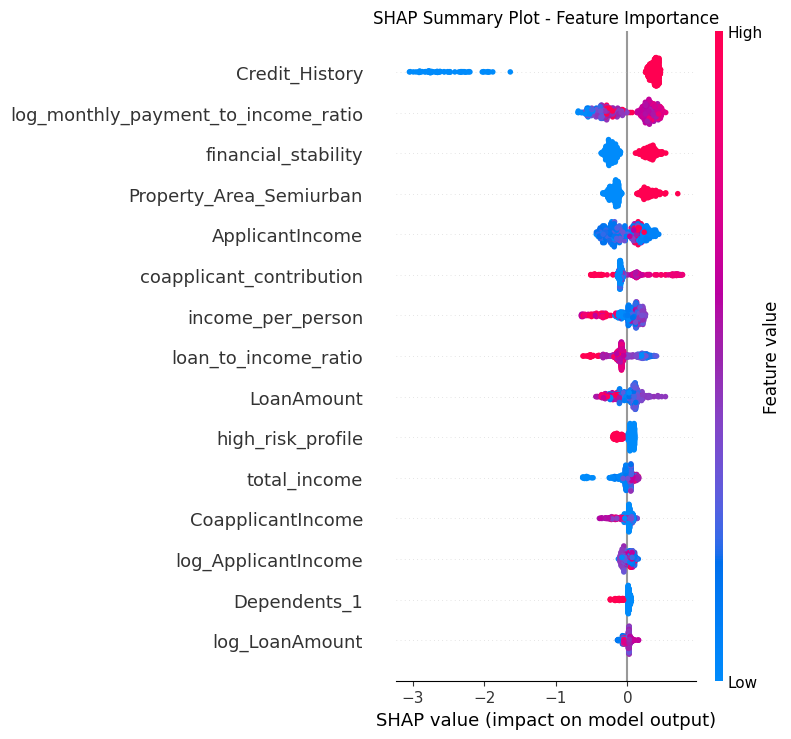

2. Creando bar plot...


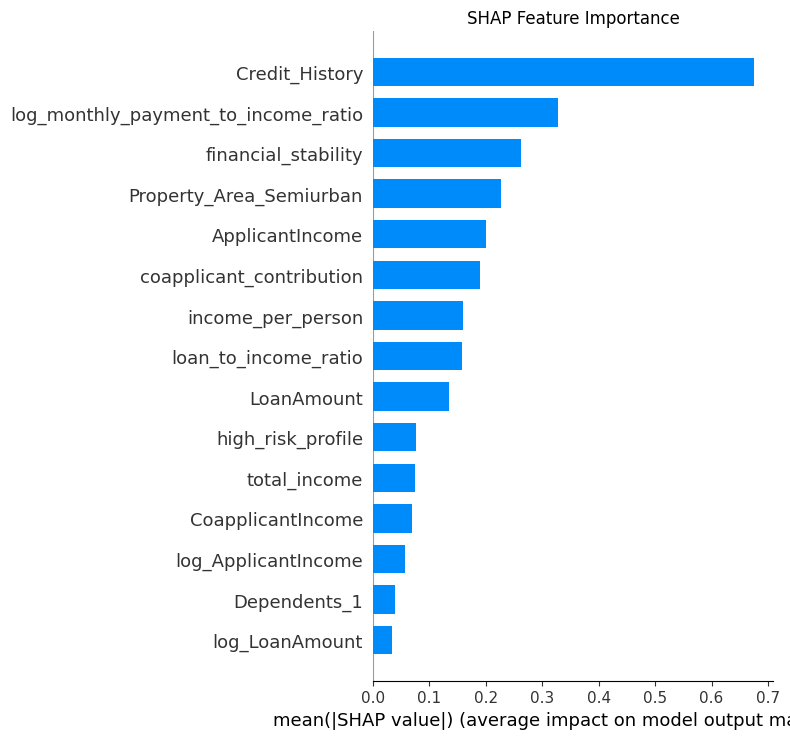

3. Creando waterfall plot para caso ejemplo...
Error creando visualizaciones: The waterfall plot requires an `Explanation` object as the `shap_values` argument.
Para crear visualizaciones manualmente:
  shap.summary_plot(shap_values, X_sample)
  shap.summary_plot(shap_values, X_sample, plot_type='bar')


In [ ]:
create_shap_visualizations(shap_results)